In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

In [ ]:
!pip install arch

## Part(c)

### Now assume that, for the first 40 years, the data consists of monthly average values rather than month-end values.Again, develop and implement an approach to estimate the same shocks (again if multiple approaches at least one of them should be the construction/simulation of daily data), explain your assumptions and limitations, and compare the results with Parts A and B.


"""
Part (c) dataset construction from the same daily source as Part (b) (``spx_50yr.csv``).

Case-study assumption:
- **First 40 years** (from first observation date): you only observe **monthly
  average** levels (here: calendar-month means of daily OHLC; sort key),
  same cut as Part (b), but ``Close`` (and O/H/L) are **averages**.
- **Last 10 years**: **daily** observations (all trading days), identical to
  Part (b).



The split date is ``daily_start = first_date + 40 years``. A month contributes
at most one low-frequency row only if that month’s **last trading day** is
strictly before ``daily_start`` (same inclusion rule as Part (b) month-end rows).

For imputing month-end levels from averages and bridged GARCH paths, use the
last 10 years of dailies (see ``part c solution.txt``); this module only builds
the **observed** Part (c) panel.


"""


In [3]:

from partc import build_part_c_dataset, build_part_c_split, split_summary
from partb import load_spx_daily

df = build_part_c_dataset()
split_summary(df)

daily_full = load_spx_daily()
monthly_avg_early, daily_recent, combined = build_part_c_split()

In [4]:
monthly_avg_early.to_csv("monthly_avg_early.csv")

In [5]:
monthly_avg_early.head()

,year_month,Date,Open,High,Low,Close,Volume,granularity
0,1976-03,1976-03-31,100.963043,101.960870,100.205652,101.084348,294222221,monthly_avg
1,1976-04,1976-04-30,101.986667,102.802857,101.136667,101.929524,217922223,monthly_avg
2,1976-05,1976-05-28,101.225500,101.904500,100.374000,101.162000,197727778,monthly_avg
3,1976-06,1976-06-30,101.584091,102.507727,100.982727,101.766818,231794447,monthly_avg
4,1976-07,1976-07-30,104.240952,104.933810,103.501905,104.200952,218755556,monthly_avg


In [6]:

from partb import (
    compute_log_returns,
    fit_t_garch_on_daily_recent,
    compare_garch_orders,
)

log_r = compute_log_returns(daily_recent)
log_r.head(), len(log_r)


(2016-03-02    0.004086
 2016-03-03    0.003493
 2016-03-04    0.003300
 2016-03-07    0.000885
 2016-03-08   -0.011304
 Name: log_return, dtype: float64,
 2513)

## 1. If you have multiple approaches at least one of them should be the construction/simulation of daily data. (DAILY CONSTRUCTION ESTIMATION)

In [7]:
# Fit GARCH(1,1)-t (default); use garch.fit for simulation later.
garch = fit_t_garch_on_daily_recent(daily_recent)
garch.params, garch.scale


({'mu': 0.0979265573355916,
  'omega': 0.020558961909627395,
  'alpha[1]': 0.16719792930117114,
  'beta[1]': 0.8302108794924186,
  'nu': 5.016668668801989},
 100.0)

In [8]:
# Optional: (1,1) vs (2,1) vs (1,2) by BIC + Ljung–Box on z^2 for chosen model
sel = compare_garch_orders(daily_recent)
sel["criteria_table"]


,p,q,loglikelihood,aic,bic,converged
0,1,1,-3106.345951,6222.691902,6251.838064,True
1,2,1,-3106.245009,6224.490018,6259.465413,True
2,1,2,-3106.345951,6224.691901,6259.667296,True


In [9]:
sel["model_selection_note"], sel["chosen_order"]
sel["ljung_box_sq_std_residuals"]


,lb_stat,lb_pvalue
1,0.769430,0.380393
2,1.082749,0.581948
3,1.126661,0.770642
4,3.817151,0.431317
5,4.464331,0.484670
6,4.920436,0.554058
7,7.127586,0.415718
8,8.442577,0.391473
9,10.436926,0.316284
10,11.067224,0.352305


#Bridge interval for a *target* calendar month = year_month row (end) + previous row (start).
#March 1996 → previous row monthly **avg** Close → March **avg** Close (``monthly_avg_early.csv``).
import pandas as pd
from partc import build_part_c_split, load_monthly_avg_csv
from partb import load_spx_daily
from partc_sim import bridge_interval_from_monthly_avg_early

daily_full = load_spx_daily()
try:
    monthly_avg_early
except NameError:
    monthly_avg_early, _, _ = build_part_c_split()

bridge_mar_1996 = bridge_interval_from_monthly_avg_early(
    monthly_avg_early, 1996, 3, daily_full=daily_full
)
pd.DataFrame([{k: bridge_mar_1996[k] for k in (
    "target_year_month",
    "previous_year_month",
    "monthly_avg_early_iloc_start",
    "monthly_avg_early_iloc_end",
    "date_start",
    "date_end",
    "date_first_trading",
    "close_first_trading",
    "avg_start",
    "avg_end",
)}])

ma_csv = load_monthly_avg_csv()
bi_csv = bridge_interval_from_monthly_avg_early(ma_csv, 1996, 3, daily_full=daily_full)
#assert bi_csv["avg_start"] == bridge_mar_1996["avg_start"]
#assert bi_csv["avg_end"] == bridge_mar_1996["avg_end"]

#PARTC_2: mean-matched daily paths + drawdown Monte Carlo (see partc_sim.py)
from partb import load_spx_daily
from partc_sim import partc2_monte_carlo, partc2_month_table

daily_full = load_spx_daily()
month_tbl = partc2_month_table(monthly_avg_early, daily_full)
month_tbl.head()


## REFERENCE FROM PART a TO TEST WHETHER THE CODE MAKES SENSE OR NOT 

In [12]:
### rolling buyhold


=== 1-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.008030  median=0.011533  skew=-0.738827  kurtosis(excess)=4.497664
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.1160 (-11.60%)  loss_mag: 0.1160
  p5:  -0.0651 (-6.51%)  loss_mag: 0.0651
  p10: -0.0437 (-4.37%)  loss_mag: 0.0437
Right-tail return quantiles (~90% / 95% / 99% gain levels):
  p90: 0.0553 (+5.53%)  gain_mag: 0.0553
  p95: 0.0711 (+7.11%)  gain_mag: 0.0711
  p99: 0.1135 (+11.35%)  gain_mag: 0.1135
Best / worst single-period return:
  Worst: -0.3167  Best: 0.2661

=== 3-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.024117  median=0.029003  skew=-0.541327  kurtosis(excess)=2.688787
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.2117 (-21.17%)  loss_mag: 0.2117
  p5:  -0.1020 (-10.20%)  loss_mag: 0.1020
  p10: -0.0648 (-6.48%)  loss_mag: 0.0648
Rig

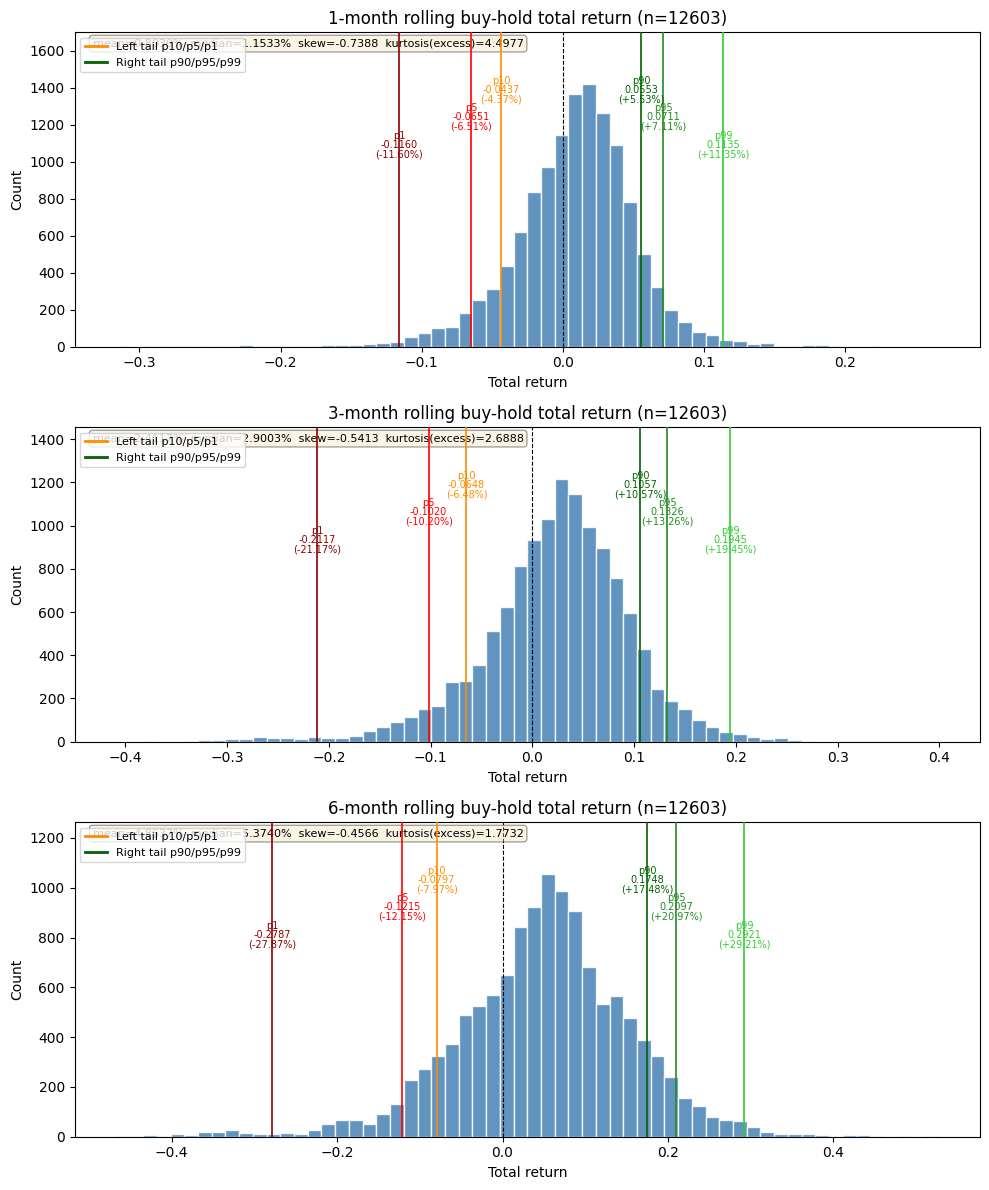

{'return_p1': -0.11601267569427189,
 'return_p5': -0.06511738096189126,
 'return_p10': -0.04369981368910305,
 'loss_magnitude_p99': 0.11601267569427189,
 'loss_magnitude_p95': 0.06511738096189126,
 'loss_magnitude_p90': 0.04369981368910305,
 'return_p90': 0.05529902757968329,
 'return_p95': 0.0711111161988406,
 'return_p99': 0.11346280066652063,
 'gain_magnitude_p90': 0.05529902757968329,
 'gain_magnitude_p95': 0.0711111161988406,
 'gain_magnitude_p99': 0.11346280066652063}

In [13]:
from spx_rolling_buyhold import analyze_spx_rolling, load_spx, rolling_calendar_month_returns, tail_loss_percentiles

out = analyze_spx_rolling()
out[1]["full_moments"]
#out[1]["right_tail_moments"]
out[1]["tail_metrics"]

### peak-to-trough drawdown

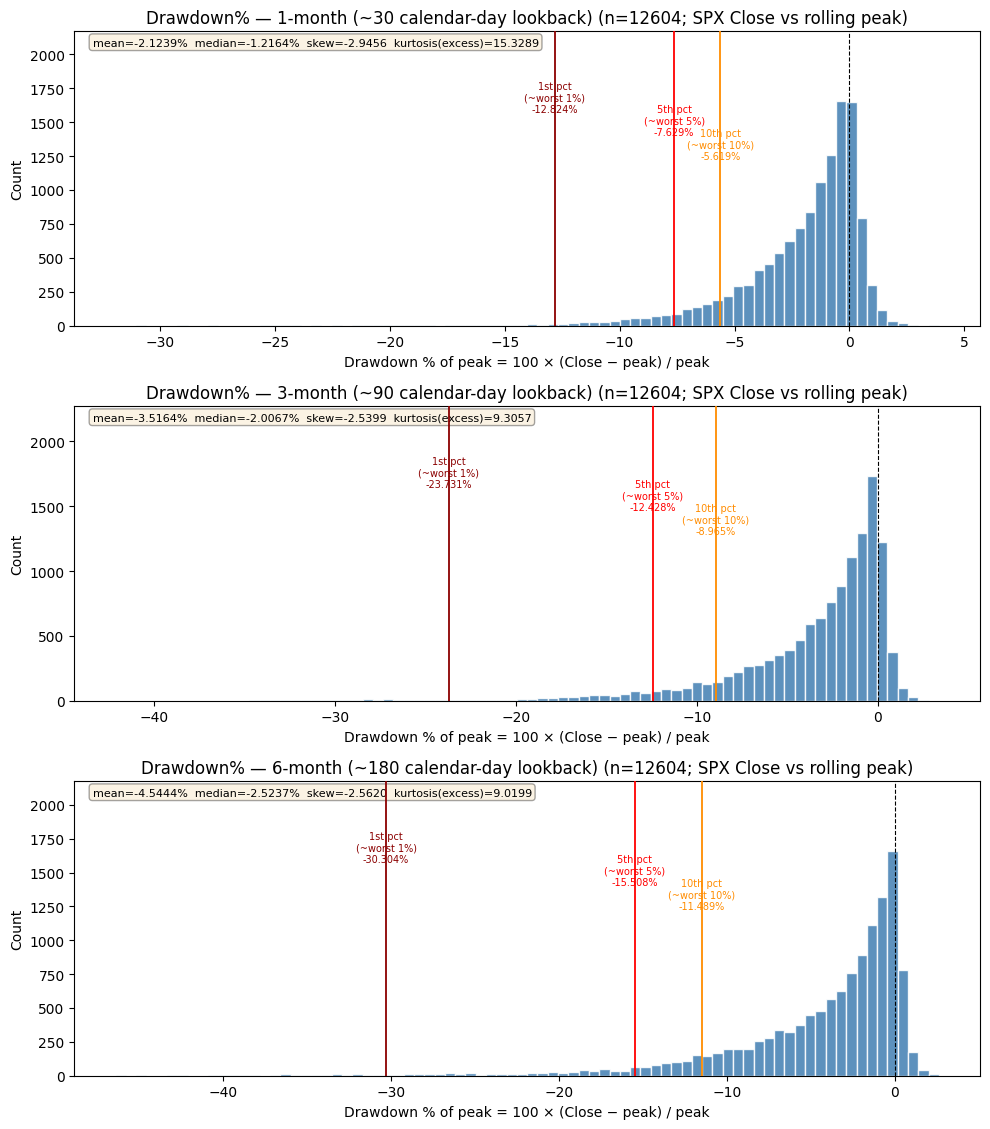

Worst-case tail: 1st / 5th / 10th pct of drawdown/peak (more negative = worse); ~99% / 95% / 90% of days are less severe. Moments on same series (fraction; ×100 = %).
  1M (~30d): n=12604  p1=-12.824%  p5=-7.629%  p10=-5.619%  |  mean=-2.1239%  median=-1.2164%  skew=-2.9456  kurtosis(excess)=15.3289
  3M (~90d): n=12604  p1=-23.731%  p5=-12.428%  p10=-8.965%  |  mean=-3.5164%  median=-2.0067%  skew=-2.5399  kurtosis(excess)=9.3057
  6M (~180d): n=12604  p1=-30.304%  p5=-15.508%  p10=-11.489%  |  mean=-4.5444%  median=-2.5237%  skew=-2.5620  kurtosis(excess)=9.0199


In [2]:
%matplotlib inline

from spx_drawdown_severity import analyze_spx_drawdown_percentiles

# ~1M / 3M / 6M calendar-day rolling peak (30 / 90 / 180 days).
out = analyze_spx_drawdown_percentiles(periods=(30, 90, 180))

## Default parametric simulation draws fresh z_t 


=== 1 calendar month (simulated pooled) ===
Observations: 1006600
  mean=0.008509  median=0.008579  skew=123.3140  kurtosis(excess)=34925.5910
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.049472
    p5: -0.073498
    p1: -0.135015
  Right tail (p90/p95/p99):
    p90: 0.063021
    p95: 0.084330
    p99: 0.147438

=== 3 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.022324  median=0.024036  skew=13.1453  kurtosis(excess)=1083.8164
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.074453
    p5: -0.109213
    p1: -0.233407
  Right tail (p90/p95/p99):
    p90: 0.112830
    p95: 0.143833
    p99: 0.227666

=== 6 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.044453  median=0.046547  skew=5.6467  kurtosis(excess)=346.6907
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.090816
    p5: -0.130413
    p1: -0.313223
  Right tail (p90/p95/p99):
    p90:

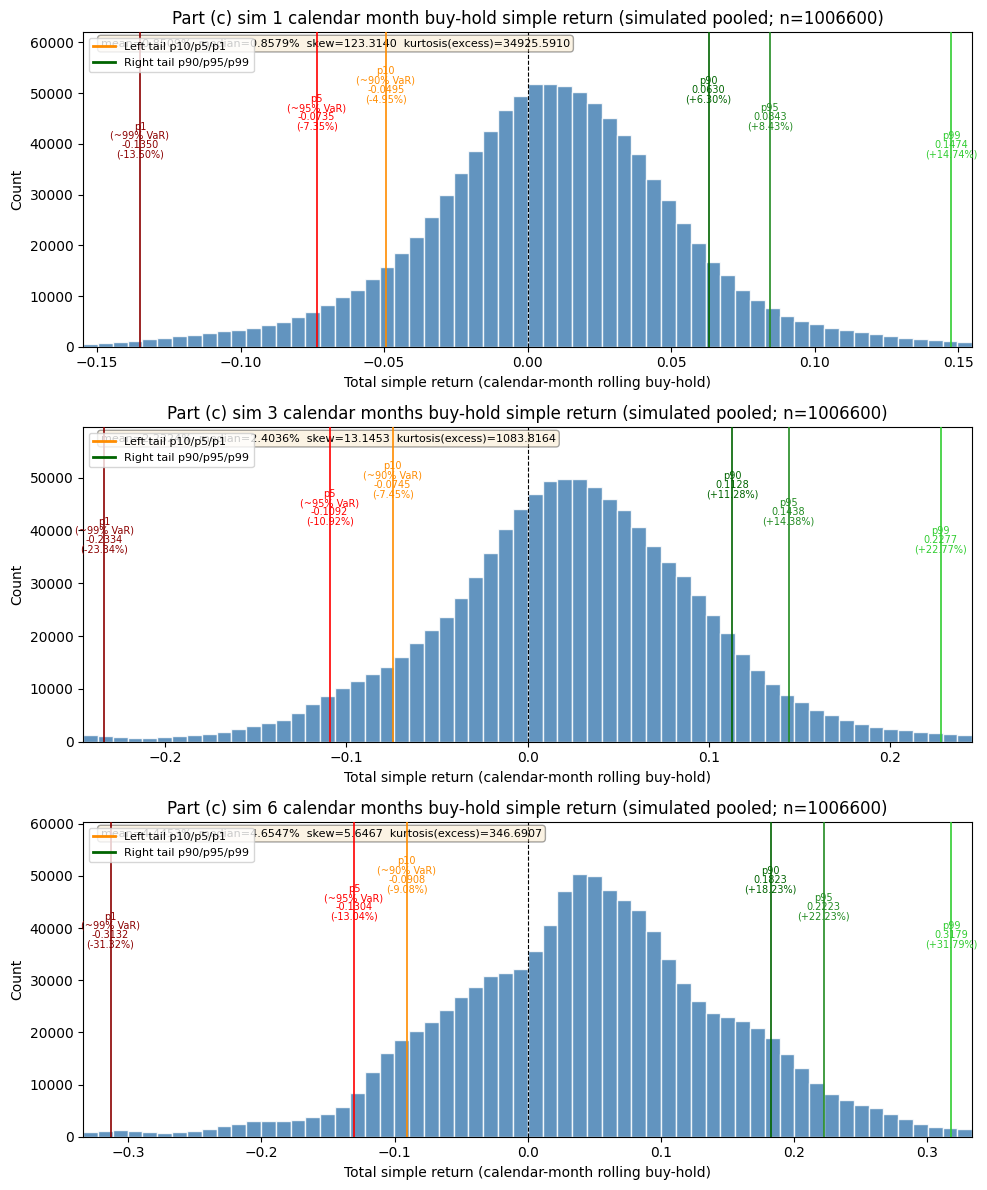

{'return_p1': -0.31322275443547853,
 'return_p5': -0.1304130933816452,
 'return_p10': -0.09081624141097724,
 'loss_magnitude_p99': 0.31322275443547853,
 'loss_magnitude_p95': 0.1304130933816452,
 'loss_magnitude_p90': 0.09081624141097724,
 'return_p90': 0.1822965144648861,
 'return_p95': 0.22226765861717002,
 'return_p99': 0.31786707377834184,
 'gain_magnitude_p90': 0.1822965144648861,
 'gain_magnitude_p95': 0.22226765861717002,
 'gain_magnitude_p99': 0.31786707377834184}

In [15]:
from spx_trading_day_buyhold import analyze_partc2_simulated_calendar_month_buyhold

cal_bh = analyze_partc2_simulated_calendar_month_buyhold(
    monthly_avg_early, daily_full, garch,
    n_paths=100,
    seed=42,
    show_plots=True,
)
cal_bh[1]["tail_metrics"]
cal_bh[3]["tail_metrics"]
cal_bh[6]["tail_metrics"]

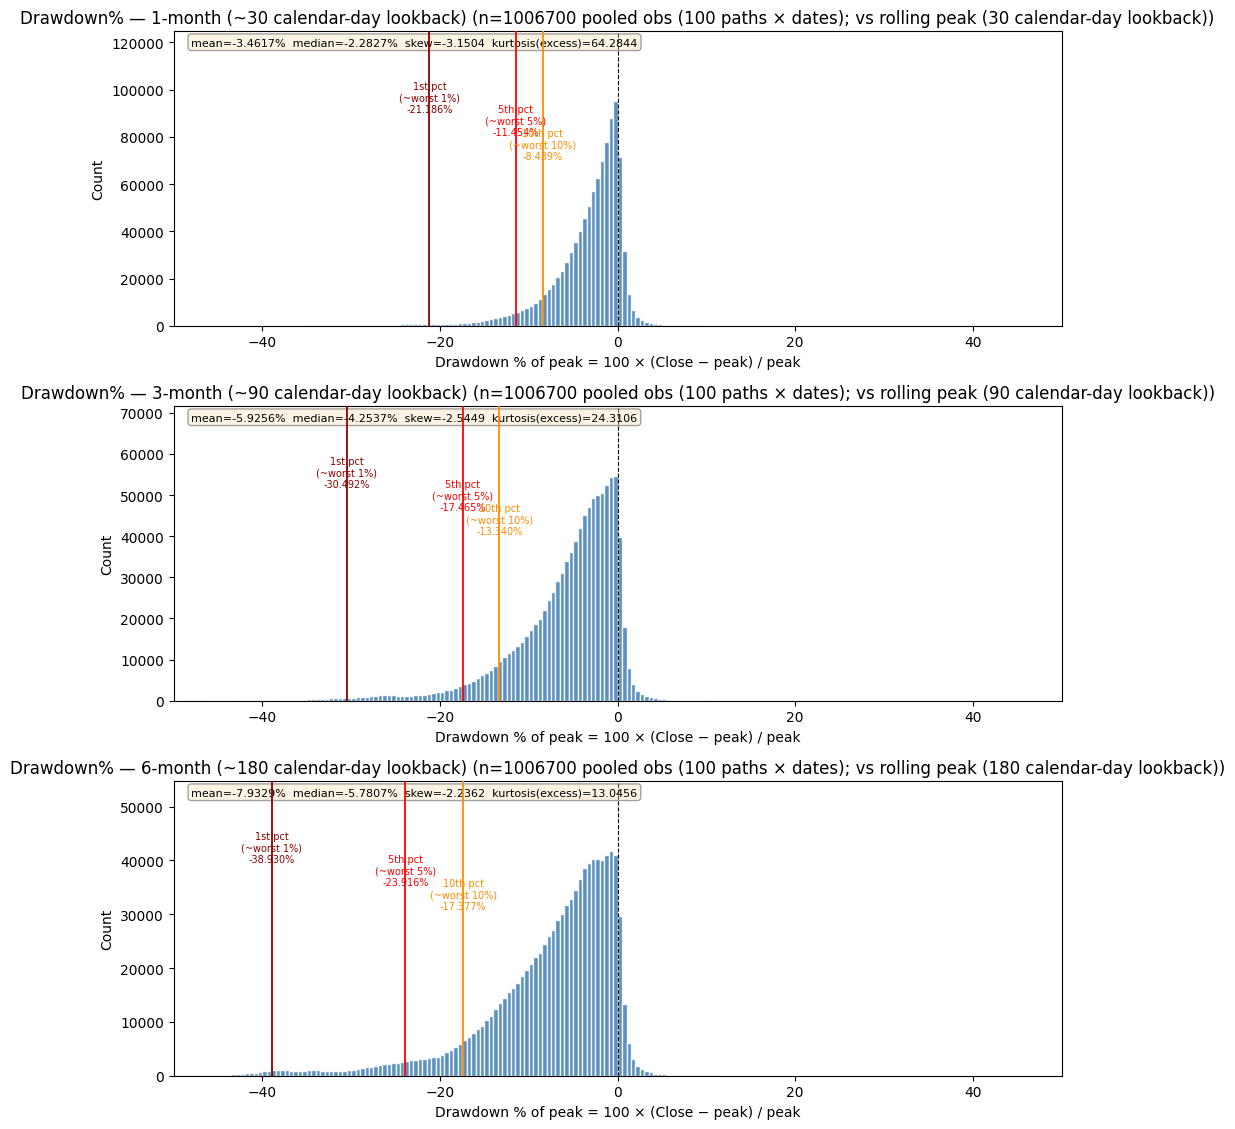

Part (c) sim — pool='pooled': same rolling-peak fractional DD as Part (a); 1st/5th/10th pct = left tail (more negative = worse).
  1M (~30d): n=1006700  p1=-21.186%  p5=-11.454%  p10=-8.439%  |  mean=-3.4617%  median=-2.2827%  skew=-3.1504  kurtosis(excess)=64.2844
  3M (~90d): n=1006700  p1=-30.492%  p5=-17.465%  p10=-13.340%  |  mean=-5.9256%  median=-4.2537%  skew=-2.5449  kurtosis(excess)=24.3106
  6M (~180d): n=1006700  p1=-38.930%  p5=-23.916%  p10=-17.377%  |  mean=-7.9329%  median=-5.7807%  skew=-2.2362  kurtosis(excess)=13.0456


In [10]:
from spx_drawdown_severity import analyze_partc2_simulated_drawdown_percentiles

dd_sim = analyze_partc2_simulated_drawdown_percentiles(
    monthly_avg_early,
    daily_full,
    garch,
    n_paths=100,
    seed=42,
    periods_calendar_days=(30, 90, 180),  # ~1m / 3m / 6m calendar days
    pool="pooled",  # or "mean_path"
    show_plots=True,
)

**Simulation (``partc_sim``):** fit t-GARCH on ``daily_recent``; each early-era month gets random GARCH log returns on the true trading calendar. Intramonth closes are **scaled** so their **mean** matches the observed monthly average (``avg_end``); the pre-month level chains from the previous month’s simulated last close (first interval uses the previous month’s ``avg_start``). This replaces Part (b)’s log-sum bridge to **month-end** levels.

## Testing simulated paths from the above application

In [17]:
from calendar import month_name

from partc_sim import (
    list_allowed_bridge_months_partc,
    month_paths_to_long_df_partc,
    simulate_partc2_month_paths,
)

# Every allowed (year, month) is a calendar month whose **last trading day** is a
# row in `monthly_avg_early` and is the **end** of a bridge segment (previous
# month **avg** Close → this month **avg** Close).
ALLOWED_YM = list_allowed_bridge_months_partc(monthly_avg_early, daily_full)
# set(ALLOWED_YM)  # uncomment to inspect


def year_month_from_name(year: int, name: str) -> tuple[int, int]:
    """Map e.g. ``year_month_from_name(2020, 'March')`` → ``(2020, 3)``."""
    n = name.strip().lower()
    for i in range(1, 13):
        if month_name[i].lower() == n:
            return year, i
    raise ValueError(f"unknown month name: {name!r}; use January … December")


# --- choose a month that exists in `monthly_avg_early` as an interval end ---
YEAR, MONTH = 1996, 3  # or: YEAR, MONTH = year_month_from_name(1996, "March")

month_mc = simulate_partc2_month_paths(
    monthly_avg_early,
    daily_full,
    garch,
    year=YEAR,
    month=MONTH,
    n_paths=30,
    seed=42,
    innovations="parametric",  # or "bootstrap" (GARCH 1,1 only)
)

# Sanity: shared pre-month level; mean of simulated daily closes = observed monthly avg
assert abs(month_mc["prices_paths"][:, 0] - month_mc["avg_start"]).max() < 1e-9
assert (
    np.abs(np.mean(month_mc["prices_paths"][:, 1:], axis=1) - month_mc["avg_end"]).max()
    < 1e-6
)

pd.DataFrame(
    {
        "date_start": [month_mc["date_start"]],
        "date_end": [month_mc["date_end"]],
        "avg_start": [month_mc["avg_start"]],
        "avg_end": [month_mc["avg_end"]],
        "n_days": [month_mc["n_trading_days"]],
        "max_abs_mean_error": [month_mc["max_abs_mean_error"]],
    }
)

# Long format: one row per (path, trading day) for charts
paths_long = month_paths_to_long_df_partc(month_mc)
paths_long.head(12)


,Date,path_id,Close_sim,row_kind
0,1996-02-29,0,649.542000,pre_month_anchor_scaled
1,1996-03-01,0,661.179948,eod
2,1996-03-04,0,652.696965,eod
3,1996-03-05,0,660.916316,eod
4,1996-03-06,0,657.685935,eod
5,1996-03-07,0,624.657656,eod
6,1996-03-08,0,634.658068,eod
7,1996-03-11,0,651.251132,eod
8,1996-03-12,0,672.946121,eod
9,1996-03-13,0,671.064985,eod


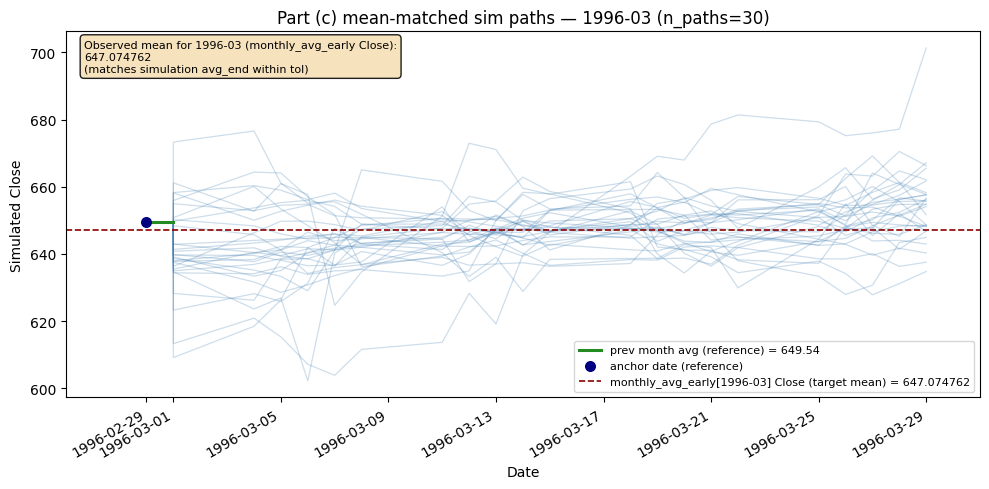

In [18]:
import matplotlib.pyplot as plt
from partc_sim import plot_partc2_month_mc_paths

# Reference: previous month avg (horizontal); simulated paths share pre-month level; first return absorbs mean rescaling.
fig, ax = plot_partc2_month_mc_paths(month_mc, monthly_avg_early=monthly_avg_early)
plt.show()

### Multi-year check (3 calendar years)

Run many chained months (same logic as single-month MC): each calendar month’s **simulated daily mean** must match `monthly_avg_early`’s `Close` for that month.

- **`simulate_partc2_year_span_batch`**: slice `partc2_month_table` to a year range, simulate `n_paths` full paths, attach **`validation_long`** / **`validation_by_month`** (per path × month errors; should be ≈0).
- **`plot_partc_year_span_validation`**: prices vs panel step means; ribbon of monthly sim means vs panel; bar of worst |error| per month across paths.
- Set **`start_year`** explicitly, or pass **`randomize_start_year=True`** (and `start_year=None`) to draw a random feasible 3-year block (same seed = reproducible).


In [19]:
import matplotlib.pyplot as plt
from partc_sim import (
    partc2_month_table,
    partc_feasible_calendar_year_starts,
    plot_partc_year_span_validation,
    simulate_partc2_year_span_batch,
)

# Feasible first calendar years for a 3-year window inside monthly_avg_efarly
mt_full_check = partc2_month_table(monthly_avg_early, daily_full)
print("example feasible start years:", partc_feasible_calendar_year_starts(mt_full_check, n_years=3)[:8], "...")

YEAR_SPAN_BATCH = simulate_partc2_year_span_batch(
    monthly_avg_early,
    daily_full,
    garch,
    start_year=2000,
    n_years=3,
    n_paths=20,
    seed=123,
    randomize_start_year=True,
    innovations="parametric",
)
print(
    "start_year", YEAR_SPAN_BATCH["start_year"],
    "n slice months", len(YEAR_SPAN_BATCH["month_table_slice"]),
    "all_ok", YEAR_SPAN_BATCH["all_ok"],
    "max_abs_error", YEAR_SPAN_BATCH["max_abs_error"],
)
assert YEAR_SPAN_BATCH["all_ok"], "every month on every path should hit panel mean"



# Optional: inspect worst months across paths
# YEAR_SPAN_BATCH["validation_by_month"].nlargest(5, "abs_err_max")


example feasible start years: [1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983] ...
start_year 2000 n slice months 36 all_ok True max_abs_error 6.821210263296962e-13


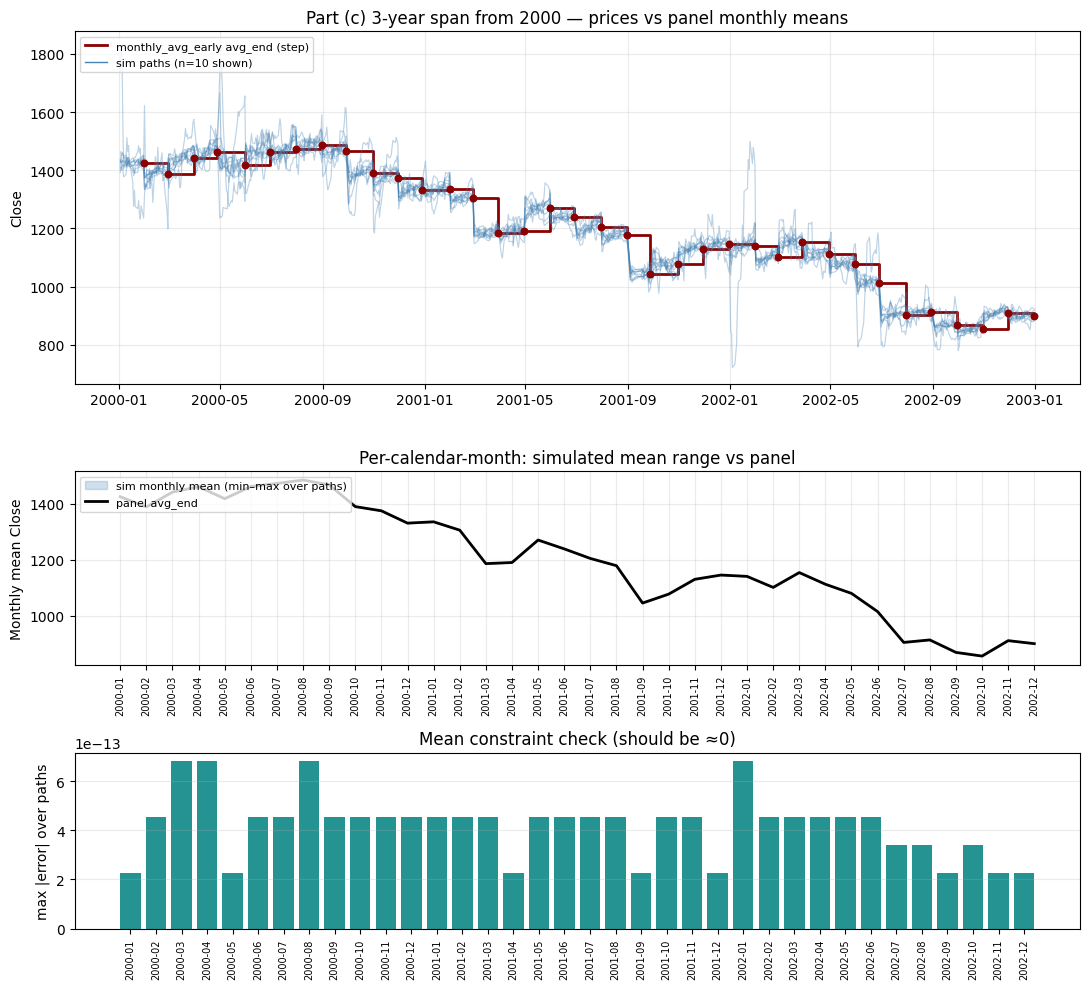

In [20]:
fig, axes = plot_partc_year_span_validation(YEAR_SPAN_BATCH, max_paths_price=10)
plt.show()

## Pros quite comparable to the reference risk metrics
## Issues [CONS] of parametric selection: unrealistic returns are possible

In [21]:
import numpy as np

# Run after `cal_bh = analyze_partc2_simulated_calendar_month_buyhold(...)`.
# For historical SPX calendar plots, use `cal_hist` instead of `cal_bh` if the structure matches.
results = cal_bh
for hm in sorted(results.keys()):
    r = np.asarray(results[hm]["returns_array"], dtype=float)
    r = r[np.isfinite(r)]
    print(f"=== {hm} calendar month(s) (n={len(r):,}) ===")
    print(f"  full sample min / max: {r.min():.6f}  /  {r.max():.6f}")
    print(f"  as %: {r.min() * 100:.4f}%  …  {r.max() * 100:.4f}%")
    # Default plot window matches `xlim_symmetric_percentiles=(1, 99)` in analyze_partc2_simulated_calendar_month_buyhold
    lo1, hi99 = np.percentile(r, [1.0, 99.0])
    m = max(abs(float(lo1)), abs(float(hi99)))
    if m == 0.0:
        m = float(np.std(r) or 0.05)
    pad = max(0.05 * m, 1e-8)
    x_lo, x_hi = -m - pad, m + pad
    print(f"  default hist x-range (~symmetric p1–p99): [{x_lo:.6f}, {x_hi:.6f}]")


=== 1 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.933999  /  30.214221
  as %: -93.3999%  …  3021.4221%
  default hist x-range (~symmetric p1–p99): [-0.154810, 0.154810]
=== 3 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.933751  /  13.899715
  as %: -93.3751%  …  1389.9715%
  default hist x-range (~symmetric p1–p99): [-0.245077, 0.245077]
=== 6 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.930787  /  13.291888
  as %: -93.0787%  …  1329.1888%
  default hist x-range (~symmetric p1–p99): [-0.333760, 0.333760]


## Bootstrap method 

### Rolling Buyhold



=== 1 calendar month (simulated pooled) ===
Observations: 1006600
  mean=0.012189  median=0.008407  skew=554.6364  kurtosis(excess)=335690.8583
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.049737
    p5: -0.074498
    p1: -0.138979
  Right tail (p90/p95/p99):
    p90: 0.062804
    p95: 0.084531
    p99: 0.149134

=== 3 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.026401  median=0.023921  skew=552.6655  kurtosis(excess)=334144.2529
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.074271
    p5: -0.109726
    p1: -0.234759
  Right tail (p90/p95/p99):
    p90: 0.112518
    p95: 0.143938
    p99: 0.229204

=== 6 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.048526  median=0.046599  skew=552.1141  kurtosis(excess)=334409.3502
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.090833
    p5: -0.131328
    p1: -0.314707
  Right tail (p90/p95/p99):

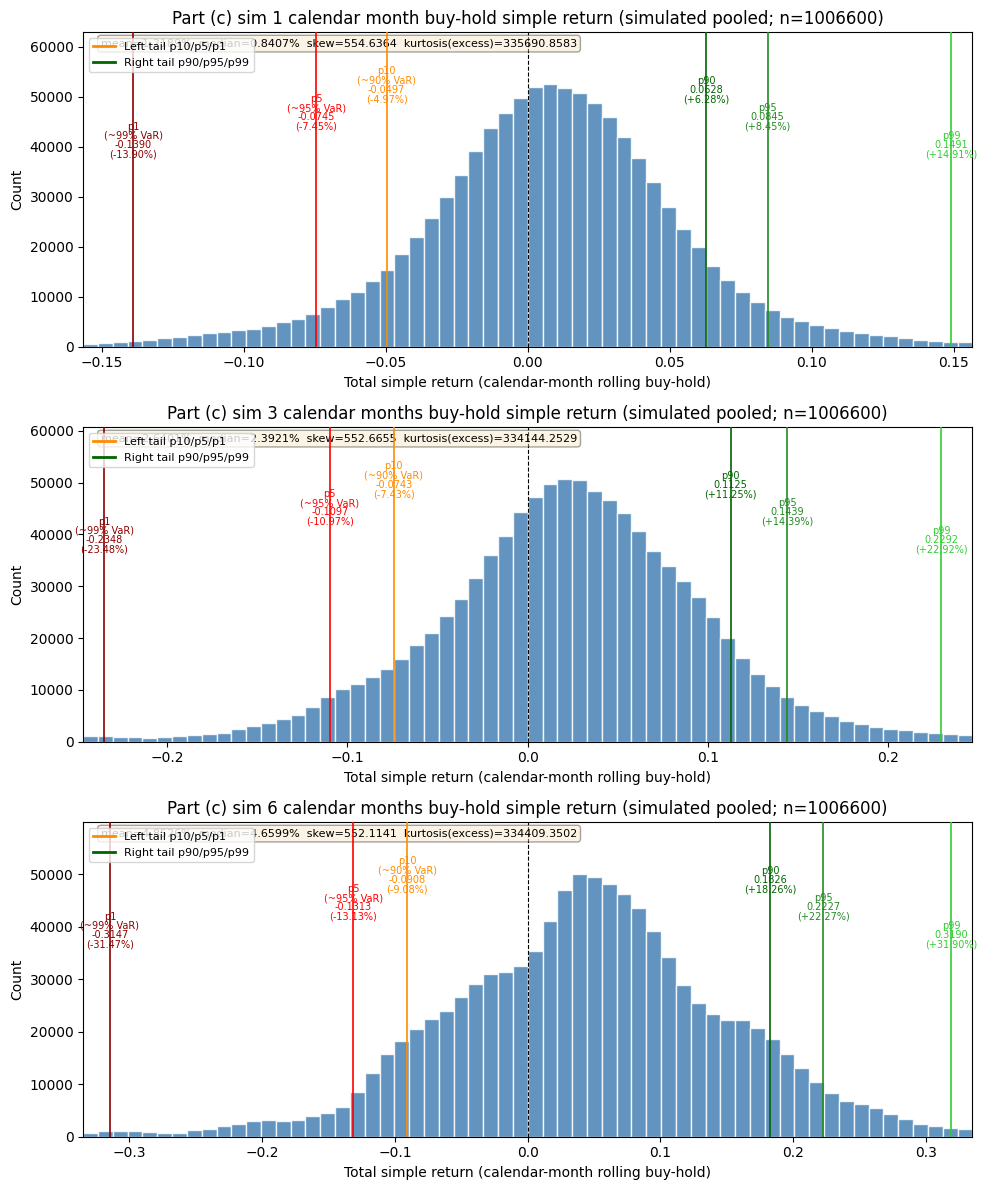

{'return_p1': -0.3147070077004547,
 'return_p5': -0.1313275963414664,
 'return_p10': -0.09083283621074724,
 'loss_magnitude_p99': 0.3147070077004547,
 'loss_magnitude_p95': 0.1313275963414664,
 'loss_magnitude_p90': 0.09083283621074724,
 'return_p90': 0.18258717484640896,
 'return_p95': 0.22266537055046454,
 'return_p99': 0.3189607504438577,
 'gain_magnitude_p90': 0.18258717484640896,
 'gain_magnitude_p95': 0.22266537055046454,
 'gain_magnitude_p99': 0.3189607504438577}

In [22]:
# Bootstrap innovations: resample in-sample standardized residuals (GARCH 1,1 only).
# See `partc_sim` / `partb_sim` docstrings for innovation options.
from spx_trading_day_buyhold import analyze_partc2_simulated_calendar_month_buyhold

cal_bh_bootstrap = analyze_partc2_simulated_calendar_month_buyhold(
    monthly_avg_early,
    daily_full,
    garch,
    n_paths=100,
    seed=42,
    innovations="bootstrap",
    show_plots=True,
)
cal_bh_bootstrap[1]["tail_metrics"]
cal_bh_bootstrap[3]["tail_metrics"]
cal_bh_bootstrap[6]["tail_metrics"]


## EVT on bootstrap-pooled calendar-month returns (Part c)

**Setup:** Same as Part (b), but simulation is **Part (c)**: paths are bridged so each month’s **mean daily Close** matches `monthly_avg_early`, with `innovations="bootstrap"` on GARCH standardized residuals.

Pooled simple returns are in `cal_bh_bootstrap[h]["returns_array"]`; we use **Y = −R** and POT/GPD + hybrid quantiles (parallel to Part (a) `horizon_evt`).

**Caveat:** pooled sample is **not iid** (overlap + shared design) — use as **descriptive** Monte Carlo tail summary.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from parta_evt import evt_summary_pooled_simple_returns, fit_gpd_exceedances, gpd_qq_points

horizons = (1, 3, 6)
rows = [evt_summary_pooled_simple_returns(cal_bh_bootstrap[h]["returns_array"], horizon_m=h) for h in horizons]
horizon_evt_bootstrap_c = pd.DataFrame(rows)
horizon_evt_bootstrap_c


,horizon_m,n,empirical_return_p1,empirical_loss_mag_1pct_tail,GPD_u,GPD_xi,n_exceed,hybrid_q99_loss_Y,hybrid_q99.5_loss_Y
0,1,1006600,-0.138979,0.138979,0.057506,0.211772,80528,0.145087,0.183962
1,3,1006600,-0.234759,0.234759,0.086465,0.169545,80528,0.210819,0.263013
2,6,1006600,-0.314707,0.314707,0.103362,0.131543,80528,0.276255,0.345224


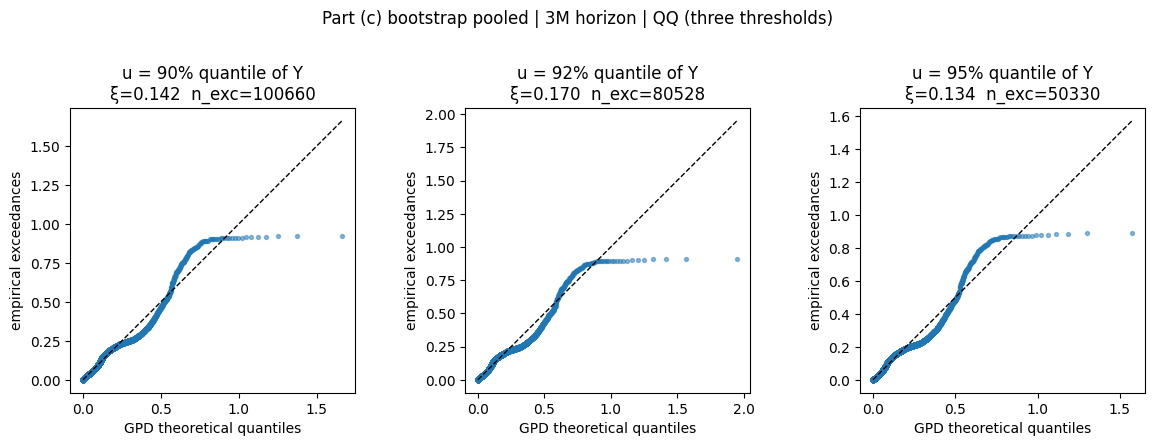

In [24]:
# QQ diagnostic: 3-calendar-month horizon — three POT thresholds (quantiles of Y = −R)
h_qq = 3
r = np.asarray(cal_bh_bootstrap[h_qq]["returns_array"], dtype=float)
r = r[np.isfinite(r)]
Y = -r
threshold_qs = (0.90, 0.92, 0.95)
fig, axes = plt.subplots(1, len(threshold_qs), figsize=(4 * len(threshold_qs), 4))
for ax, q in zip(np.atleast_1d(axes), threshold_qs):
    u_star = float(np.quantile(Y, q))
    fit = fit_gpd_exceedances(Y, u_star, min_exceedances=80)
    w = Y[Y > u_star] - u_star
    w = w[w > 0]
    emp_qq, theo_qq = gpd_qq_points(w, fit.xi, fit.sigma)
    ax.scatter(theo_qq, emp_qq, s=8, alpha=0.5)
    lim = float(max(emp_qq.max(), theo_qq.max()))
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("GPD theoretical quantiles")
    ax.set_ylabel("empirical exceedances")
    ax.set_title(
        f"u = {int(q * 100)}% quantile of Y\nξ={fit.xi:.3f}  n_exc={fit.n_exceedances}"
    )
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Part (c) bootstrap pooled | 3M horizon | QQ (three thresholds)", y=1.06)
plt.tight_layout()
plt.show()


### Peak-to-Trough Drawdown

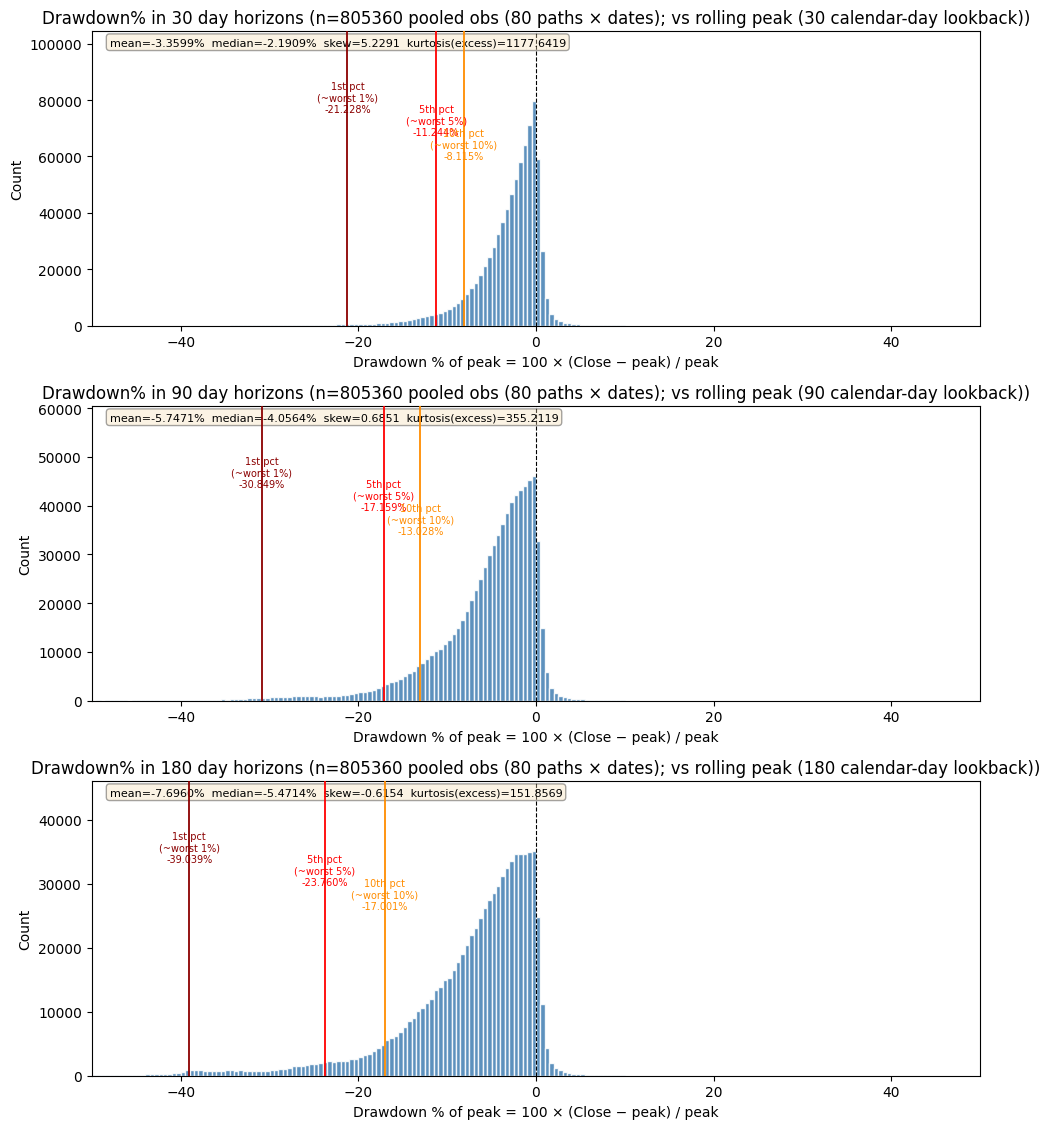

Part (c) sim — pool='pooled': same rolling-peak fractional DD as Part (a); 1st/5th/10th pct = left tail (more negative = worse).
  30-day: n=805360  p1=-21.228%  p5=-11.244%  p10=-8.115%  |  mean=-3.3599%  median=-2.1909%  skew=5.2291  kurtosis(excess)=1177.6419
  90-day: n=805360  p1=-30.849%  p5=-17.159%  p10=-13.028%  |  mean=-5.7471%  median=-4.0564%  skew=0.6851  kurtosis(excess)=355.2119
  180-day: n=805360  p1=-39.039%  p5=-23.760%  p10=-17.001%  |  mean=-7.6960%  median=-5.4714%  skew=-0.6154  kurtosis(excess)=151.8569


In [25]:
from spx_drawdown_severity import analyze_partc2_simulated_drawdown_percentiles

dd_sim = analyze_partc2_simulated_drawdown_percentiles(
    monthly_avg_early,
    daily_full,
    garch,
    n_paths=80,
    seed=42,
    periods_calendar_days=(30, 90, 180),  # ~1m / 3m / 6m calendar days
    pool="pooled",  # or "mean_path"
    innovations="bootstrap",
    show_plots=True,
)

## Testing simulated paths from the bootstrap method application

In [26]:
from calendar import month_name

from partc_sim import (
    list_allowed_bridge_months_partc,
    month_paths_to_long_df_partc,
    simulate_partc2_month_paths,
)

# Every allowed (year, month) is a calendar month whose **last trading day** is a
# row in `monthly_avg_early` and is the **end** of a bridge segment (previous
# month **avg** Close → this month **avg** Close).
ALLOWED_YM = list_allowed_bridge_months_partc(monthly_avg_early, daily_full)
# set(ALLOWED_YM)  # uncomment to inspect


def year_month_from_name(year: int, name: str) -> tuple[int, int]:
    """Map e.g. ``year_month_from_name(2020, 'March')`` → ``(2020, 3)``."""
    n = name.strip().lower()
    for i in range(1, 13):
        if month_name[i].lower() == n:
            return year, i
    raise ValueError(f"unknown month name: {name!r}; use January … December")


# --- choose a month that exists in `monthly_avg_early` as an interval end ---
YEAR, MONTH = 1996, 3  # or: YEAR, MONTH = year_month_from_name(1996, "March")

month_mc = simulate_partc2_month_paths(
    monthly_avg_early,
    daily_full,
    garch,
    year=YEAR,
    month=MONTH,
    n_paths=30,
    seed=42,
    innovations="bootstrap",  # or "bootstrap" (GARCH 1,1 only)
)

# Sanity: shared pre-month level; mean of simulated daily closes = observed monthly avg
assert abs(month_mc["prices_paths"][:, 0] - month_mc["avg_start"]).max() < 1e-9
assert (
    np.abs(np.mean(month_mc["prices_paths"][:, 1:], axis=1) - month_mc["avg_end"]).max()
    < 1e-6
)

pd.DataFrame(
    {
        "date_start": [month_mc["date_start"]],
        "date_end": [month_mc["date_end"]],
        "avg_start": [month_mc["avg_start"]],
        "avg_end": [month_mc["avg_end"]],
        "n_days": [month_mc["n_trading_days"]],
        "max_abs_mean_error": [month_mc["max_abs_mean_error"]],
    }
)

# Long format: one row per (path, trading day) for charts
paths = month_paths_to_long_df_partc(month_mc)
paths.head(12)


,Date,path_id,Close_sim,row_kind
0,1996-02-29,0,649.542000,pre_month_anchor_scaled
1,1996-03-01,0,648.139157,eod
2,1996-03-04,0,644.762935,eod
3,1996-03-05,0,645.796151,eod
4,1996-03-06,0,645.383573,eod
5,1996-03-07,0,647.323318,eod
6,1996-03-08,0,646.696977,eod
7,1996-03-11,0,645.072449,eod
8,1996-03-12,0,640.999011,eod
9,1996-03-13,0,641.348581,eod


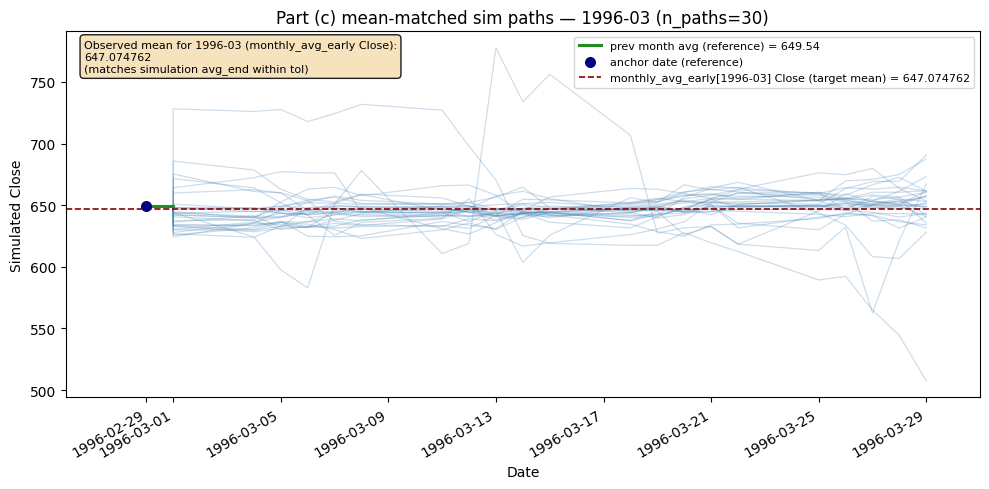

In [27]:
import matplotlib.pyplot as plt
from partc_sim import plot_partc2_month_mc_paths

# Part (c): shared pre-month level from previous month’s panel avg; mean rescaling on intramonth closes.
fig, ax = plot_partc2_month_mc_paths(month_mc, monthly_avg_early=monthly_avg_early)
plt.show()

In [28]:
import matplotlib.pyplot as plt
from partc_sim import (
    partc2_month_table,
    partc_feasible_calendar_year_starts,
    plot_partc_year_span_validation,
    simulate_partc2_year_span_batch,
)

# Feasible first calendar years for a 3-year window inside monthly_avg_early
mt_full_check = partc2_month_table(monthly_avg_early, daily_full)
print("example feasible start years:", partc_feasible_calendar_year_starts(mt_full_check, n_years=3)[:8], "...")

YEAR_SPAN_BATCH = simulate_partc2_year_span_batch(
    monthly_avg_early,
    daily_full,
    garch,
    start_year=2000,
    n_years=3,
    n_paths=100,
    seed=123,
    randomize_start_year=True,
    innovations="parametric",
)
print(
    "start_year", YEAR_SPAN_BATCH["start_year"],
    "n slice months", len(YEAR_SPAN_BATCH["month_table_slice"]),
    "all_ok", YEAR_SPAN_BATCH["all_ok"],
    "max_abs_error", YEAR_SPAN_BATCH["max_abs_error"],
)
assert YEAR_SPAN_BATCH["all_ok"], "every month on every path should hit panel mean"



# Optional: inspect worst months across paths
# YEAR_SPAN_BATCH["validation_by_month"].nlargest(5, "abs_err_max")


example feasible start years: [1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983] ...
start_year 2000 n slice months 36 all_ok True max_abs_error 6.821210263296962e-13


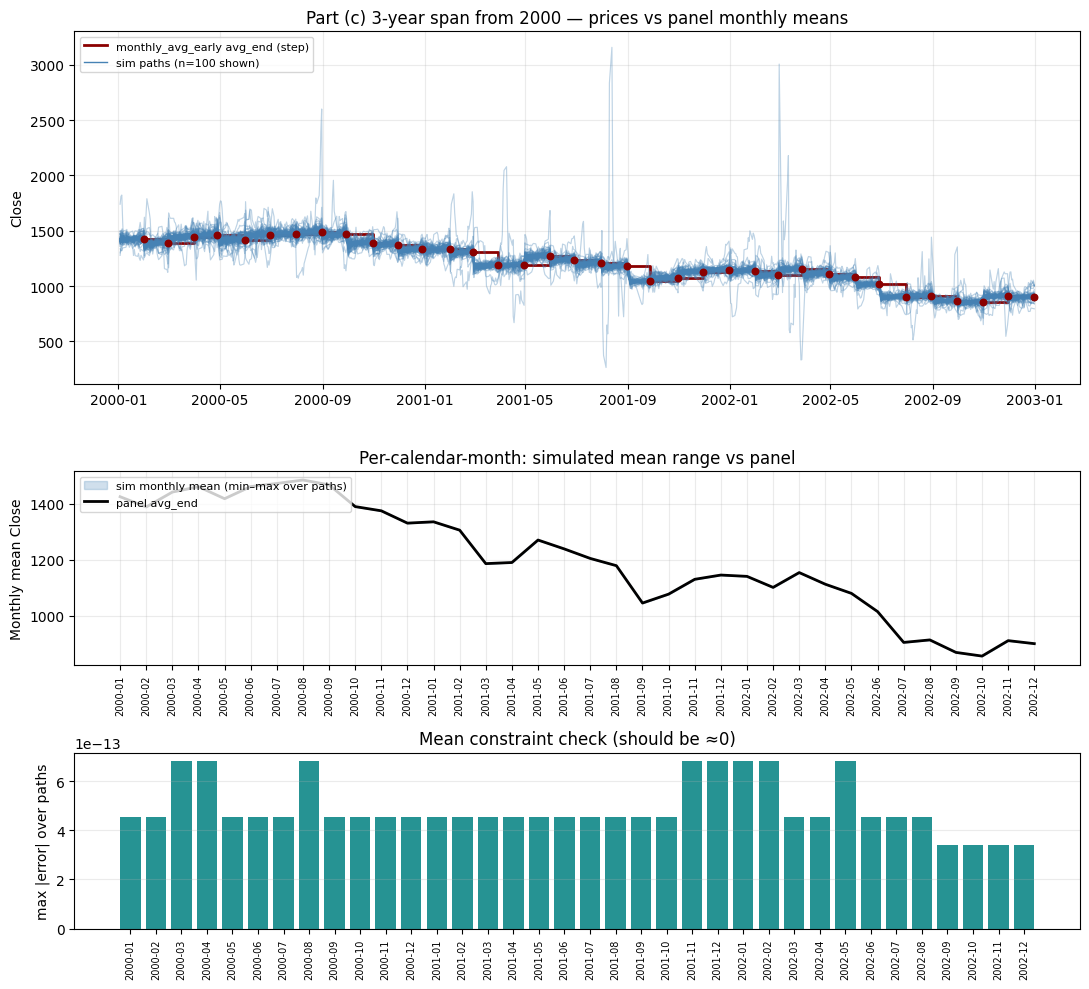

In [29]:
fig, axes = plot_partc_year_span_validation(YEAR_SPAN_BATCH, max_paths_price=100)
plt.show()

## Pros quite comparable to the reference risk metrics
## Issues [CONS] of bootstrap method 

In [30]:
import numpy as np

# Run after `cal_bh = analyze_partc2_simulated_calendar_month_buyhold(...)`.
# For historical SPX calendar plots, use `cal_hist` instead of `cal_bh` if the structure matches.
results = cal_bh_bootstrap
for hm in sorted(results.keys()):
    r = np.asarray(results[hm]["returns_array"], dtype=float)
    r = r[np.isfinite(r)]
    print(f"=== {hm} calendar month(s) (n={len(r):,}) ===")
    print(f"  full sample min / max: {r.min():.6f}  /  {r.max():.6f}")
    print(f"  as %: {r.min() * 100:.4f}%  …  {r.max() * 100:.4f}%")
    # Default plot window matches `xlim_symmetric_percentiles=(1, 99)` in analyze_partc2_simulated_calendar_month_buyhold
    lo1, hi99 = np.percentile(r, [1.0, 99.0])
    m = max(abs(float(lo1)), abs(float(hi99)))
    if m == 0.0:
        m = float(np.std(r) or 0.05)
    pad = max(0.05 * m, 1e-8)
    x_lo, x_hi = -m - pad, m + pad
    print(f"  default hist x-range (~symmetric p1–p99): [{x_lo:.6f}, {x_hi:.6f}]")

=== 1 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.998884  /  958.512154
  as %: -99.8884%  …  95851.2154%
  default hist x-range (~symmetric p1–p99): [-0.156590, 0.156590]
=== 3 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.998728  /  985.178041
  as %: -99.8728%  …  98517.8041%
  default hist x-range (~symmetric p1–p99): [-0.246497, 0.246497]
=== 6 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.998724  /  992.492867
  as %: -99.8724%  …  99249.2867%
  default hist x-range (~symmetric p1–p99): [-0.334909, 0.334909]


### Pooled min/max rolling calendar returns — **`CAL_ROLL_EXTREMA`**

**Execution order:** run the **next code cell only after** `analyze_partc2_simulated_calendar_month_buyhold` has produced `cal_bh` and/or `cal_bh_bootstrap`. This block is near the top for visibility only — it **will fail** if those objects are not defined yet. Set `CAL_EXTREMA_MODE` to `"parametric"` or `"bootstrap"` and keep `_CAL_BH_KW` aligned with the matching `analyze_*` call (`seed`, `n_paths`, `burn`, `innovations`, `horizons_months`).

In [31]:
# Pooled min/max rolling calendar windows + daily Close paths → CAL_ROLL_EXTREMA
CAL_EXTREMA_MODE = "parametric"  # "parametric" → needs cal_bh | "bootstrap" → needs cal_bh_bootstrap

import numpy as np
from partc_sim import (
    partc2_pool_calendar_month_returns_detailed,
    simulate_partc2_path_at_pool_index,
    partc_close_series_for_calendar_window,
)

if CAL_EXTREMA_MODE == "parametric":
    _CAL_BH_KW = dict(
        horizons_months=(1, 3, 6), n_paths=100, seed=42, burn=500, innovations="parametric"
    )
    results = cal_bh
elif CAL_EXTREMA_MODE == "bootstrap":
    _CAL_BH_KW = dict(
        horizons_months=(1, 3, 6), n_paths=100, seed=42, burn=500, innovations="bootstrap"
    )
    results = cal_bh_bootstrap
else:
    raise ValueError(f"CAL_EXTREMA_MODE={CAL_EXTREMA_MODE!r}; use 'parametric' or 'bootstrap'")

cal_returns_detail = partc2_pool_calendar_month_returns_detailed(
    monthly_avg_early, daily_full, garch, **_CAL_BH_KW
)
CAL_ROLL_EXTREMA = {}

for hm in sorted(results.keys()):
    r = np.asarray(results[hm]["returns_array"], dtype=float)
    r = r[np.isfinite(r)]
    print(f"=== {hm} calendar month(s) (n={len(r):,}) ===")
    print(f"  full sample min / max: {r.min():.6f}  /  {r.max():.6f}")
    print(f"  as %: {r.min() * 100:.4f}%  …  {r.max() * 100:.4f}%")
    lo1, hi99 = np.percentile(r, [1.0, 99.0])
    m = max(abs(float(lo1)), abs(float(hi99)))
    if m == 0.0:
        m = float(np.std(r) or 0.05)
    pad = max(0.05 * m, 1e-8)
    x_lo, x_hi = -m - pad, m + pad
    print(f"  default hist x-range (~symmetric p1–p99): [{x_lo:.6f}, {x_hi:.6f}]")

    dfp = cal_returns_detail[hm]
    r_worst = dfp.loc[dfp["return"].idxmin()]
    r_best = dfp.loc[dfp["return"].idxmax()]
    print("  --- min return window (path_id, dates, prices) ---")
    print(r_worst[["path_id", "start_date", "end_date", "start_price", "end_price", "return"]].to_string())
    print("  --- max return window ---")
    print(r_best[["path_id", "start_date", "end_date", "start_price", "end_price", "return"]].to_string())

    p_lo = simulate_partc2_path_at_pool_index(
        monthly_avg_early,
        daily_full,
        garch,
        path_index=int(r_worst["path_id"]),
        n_paths=_CAL_BH_KW["n_paths"],
        seed=_CAL_BH_KW["seed"],
        burn=_CAL_BH_KW["burn"],
        innovations=_CAL_BH_KW["innovations"],
    )
    s_lo = partc_close_series_for_calendar_window(p_lo, r_worst["start_date"], r_worst["end_date"])
    p_hi = simulate_partc2_path_at_pool_index(
        monthly_avg_early,
        daily_full,
        garch,
        path_index=int(r_best["path_id"]),
        n_paths=_CAL_BH_KW["n_paths"],
        seed=_CAL_BH_KW["seed"],
        burn=_CAL_BH_KW["burn"],
        innovations=_CAL_BH_KW["innovations"],
    )
    s_hi = partc_close_series_for_calendar_window(p_hi, r_best["start_date"], r_best["end_date"])
    CAL_ROLL_EXTREMA[hm] = {
        "row_min": r_worst,
        "row_max": r_best,
        "series_min": s_lo,
        "series_max": s_hi,
    }

=== 1 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.933999  /  30.214221
  as %: -93.3999%  …  3021.4221%
  default hist x-range (~symmetric p1–p99): [-0.154810, 0.154810]
  --- min return window (path_id, dates, prices) ---
path_id                         21
start_date     1983-09-15 00:00:00
end_date       1983-10-14 00:00:00
start_price             167.273981
end_price                11.040283
return                   -0.933999
  --- max return window ---
path_id                         92
start_date     1976-12-02 00:00:00
end_date       1976-12-31 00:00:00
start_price              14.043274
end_price               438.349868
return                   30.214221
=== 3 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.933751  /  13.899715
  as %: -93.3751%  …  1389.9715%
  default hist x-range (~symmetric p1–p99): [-0.245077, 0.245077]
  --- min return window (path_id, dates, prices) ---
path_id                         21
start_date     1983-07-15 00:00